Importing Libraries

In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
from IPython.display import display

Creating a Custom U3 Gate

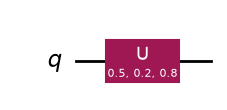

In [2]:
u3_circuit = QuantumCircuit(1)
u3_circuit.u(0.5, 0.2, 0.8, 0)
u3_circuit.draw('mpl')

Converting to a Gate and Adding Control

In [3]:
u3_gate = u3_circuit.to_gate(label='U3')
cu3_gate = u3_gate.control(1, label='CU3')

Building a Composite Gate

In [4]:
composite = QuantumCircuit(3, name='MyCompositeGate')
composite.h(0)
composite.append(cu3_gate, [0, 1])
composite.cx(1, 2)
composite_gate = composite.to_gate()

Using the Composite Gate in a Circuit

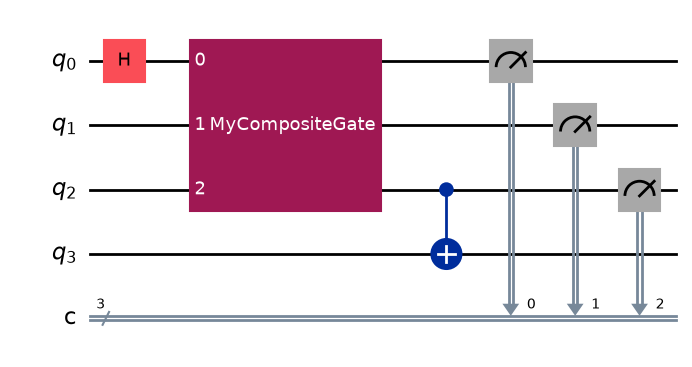

In [5]:
qc = QuantumCircuit(4, 3)
qc.h(0)
qc.append(composite_gate, [0, 1, 2])
qc.cx(2, 3)
qc.measure([0, 1, 2], [0, 1, 2])
qc.draw('mpl')

Simulating the Circuit

Measurement results: {'000': 1024}


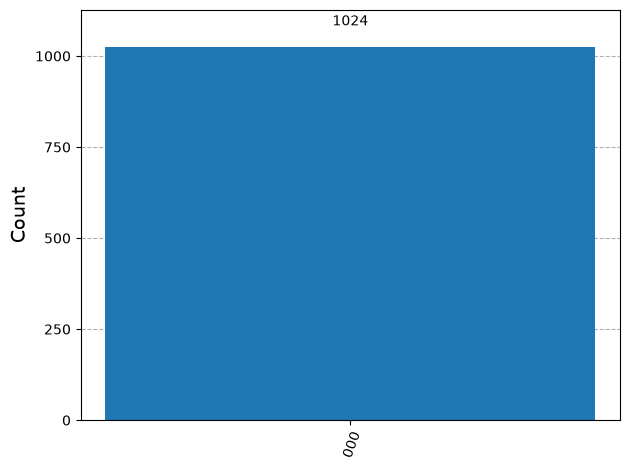

In [6]:
simulator = AerSimulator()
compiled_qc = transpile(qc, simulator)
job = simulator.run(compiled_qc, shots=1024)
counts = job.result().get_counts()

print("Measurement results:", counts)
fig = plot_histogram(counts)
display(fig)

Complete Code

Measurement results: {'000': 1024}


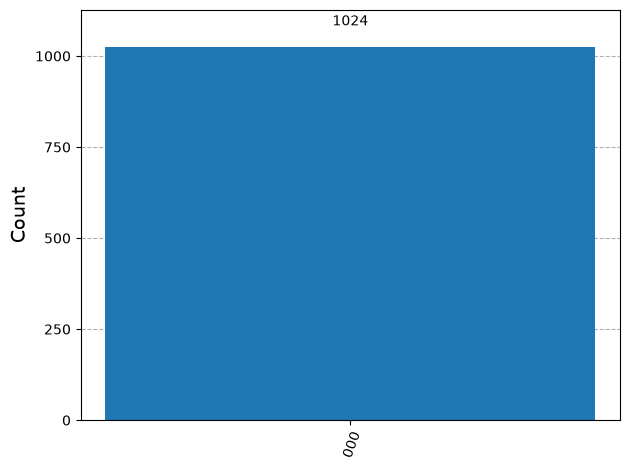

In [7]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

u3_circuit = QuantumCircuit(1)
u3_circuit.u(0.5, 0.2, 0.8, 0)

u3_gate = u3_circuit.to_gate(label='U3')
cu3_gate = u3_gate.control(1, label='CU3')

composite = QuantumCircuit(3, name='MyCompositeGate')
composite.h(0)
composite.append(cu3_gate, [0, 1])
composite.cx(1, 2)
composite_gate = composite.to_gate()

qc = QuantumCircuit(4, 3)
qc.h(0)
qc.append(composite_gate, [0, 1, 2])
qc.cx(2, 3)
qc.measure([0, 1, 2], [0, 1, 2])

simulator = AerSimulator()
compiled_qc = transpile(qc, simulator)
job = simulator.run(compiled_qc, shots=1024)
counts = job.result().get_counts()

print("Measurement results:", counts)
fig = plot_histogram(counts)
display(fig)